# Computing average FRC for Vietoris-Rips complexes:

--- 

This can be computing in two ways:

1. By recomputing the FRC computation for geometric simplicial complex for different cutoff value using `ff.GeometricSimplicialComplex`;
2. By using the evolving cutoff algorithm performed in `ff.VietorisRipsComplex`

The method 1 is optimized from the results of , whists the method 2 are based from [1] the recent FRC decomposition method from [2].

[1] [Efficient set-theoretic algorithms for computing high-order Forman-Ricci curvature on abstract simplicial complexes, Danillo Barros de Souza et al](https://royalsocietypublishing.org/rspa/article-abstract/481/2309/20240364/86870/Efficient-set-theoretic-algorithms-for-computing?redirectedFrom=fulltext)

[2] [Efficient Decomposition of Forman-Ricci Curvature on Vietoris-Rips Complexes and Data Applications
Danillo Barros de Souza et al](https://arxiv.org/abs/2504.21601)

---

Importing libraries:

In [1]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from time import time
import matplotlib.pyplot as plt

Importing `fastforman` (make sure it is properly installed):

In [2]:
import fastforman as ff

* Latest version: **0.7.0**:

In [3]:
ff.__version__

'0.7.0'

Fastforman computes the combinatorial Forman-Ricci curvature (FRC) for

* Geometric Simplicial complexes;
* Vietoris-Rips complexes.

In [4]:
help(ff)

Help on package fastforman:

NAME
    fastforman - # fastforman/__init__.py

PACKAGE CONTENTS
    GeometricSimplicialComplex
    VietorisRipsComplex

VERSION
    0.7.0

FILE
    /home/danillo-souza/anaconda3/lib/python3.13/site-packages/fastforman/__init__.py




# Computing average FRC for Geometric simplicial complexes:

In [73]:
#You can either change or remove the random seed
np.random.seed(42)
data=np.random.uniform(0,1,(20,3))
M=cdist(data,data)

Example:

In [12]:
D={i:M[i] for i in range(M.shape[0])}
ff.GeometricSimplicialComplex.compute_average_FRC(M,cutoff=0.5,max_dim=3)

{1: 1.5813953488372092, 2: 3.2857142857142856, 3: 4.4}

* Method 1:

In [13]:
cutoffs=[round(i,3) for i in np.arange(0,1.501,0.001)]
#D={i:M[i] for i in range(M.shape[0])}

SF={1:[],2:[],3:[]}
t0=time()
for c in cutoffs:
    aux=ff.GeometricSimplicialComplex.compute_average_FRC(np.round(M,4),c,None,3)
    SF[1].append(aux[1])
    SF[2].append(aux[2])
    SF[3].append(aux[3])
t1=time()
stime=t1-t0

# Computing average FRC for VR complexes:

* Method 2:

In [19]:
t0=time()
Fa,Ft=ff.VietorisRipsComplex.compute_local_FRC(data,3,0,1.5,precision=3)
t1=time()
ftime=t1-t0

Total ricci computation time: 0.16455459594726562 seconds.

Total pos processing time: 0.007029294967651367 seconds.

Total computation time: 0.171583890914917 seconds.



* Comparing the results:

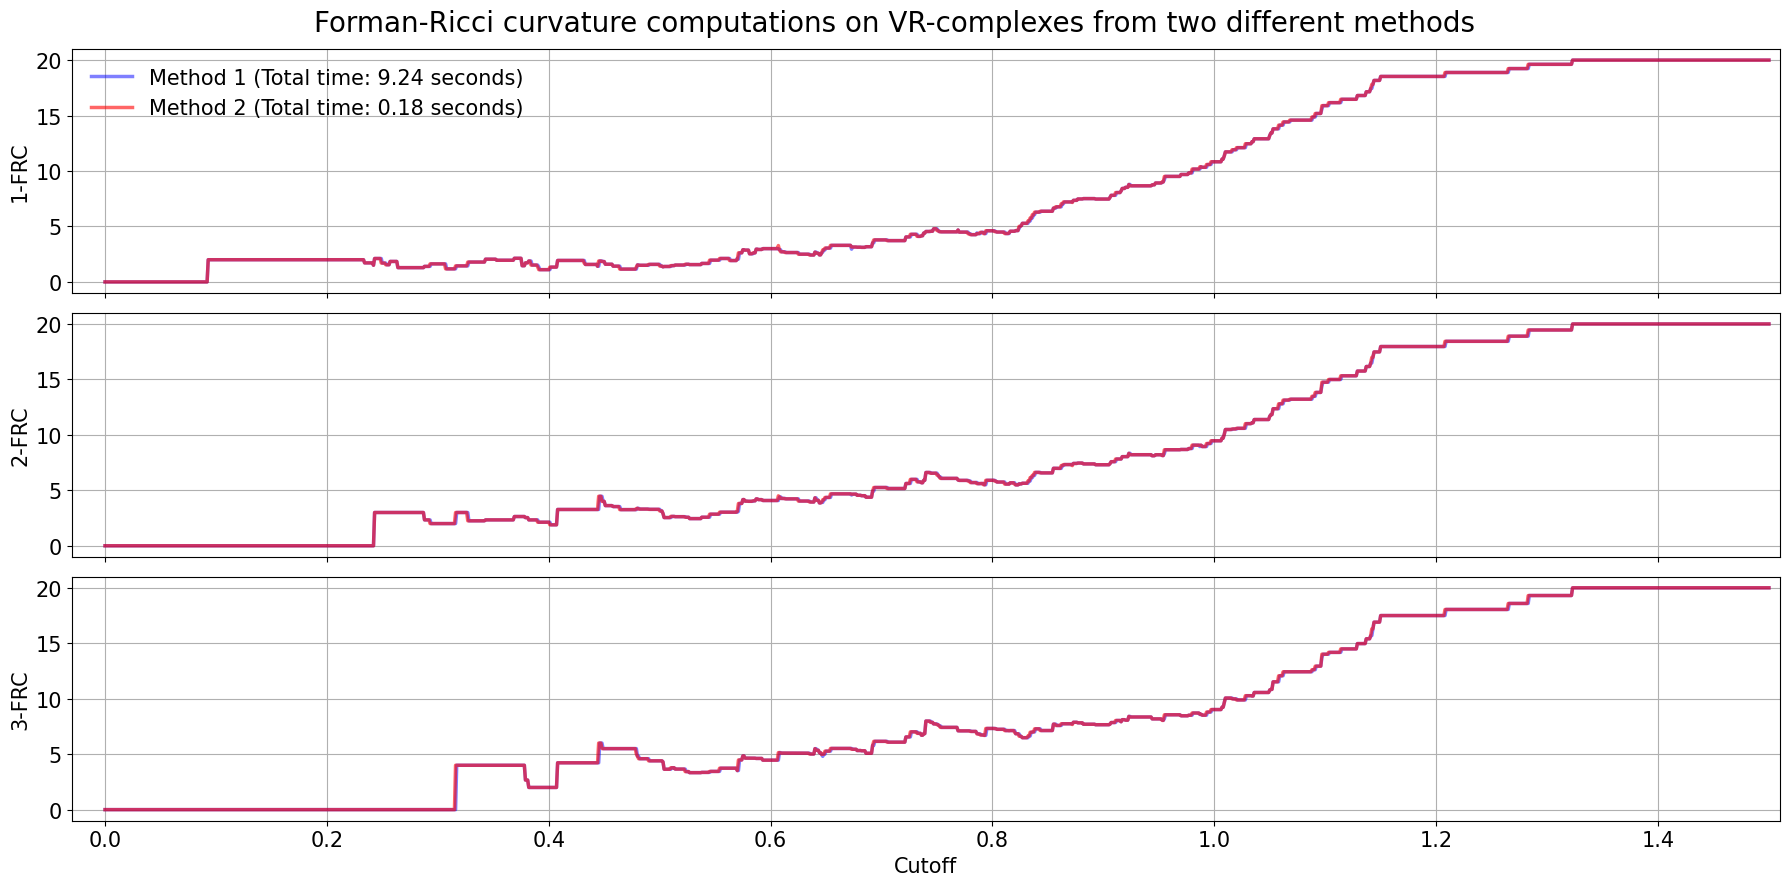

In [77]:
import matplotlib.pyplot as plt
import pandas as pd

plt.close("all")

fig, axs = plt.subplots(3, 1, figsize=(18, 9), sharex=True)
fig.suptitle(
    "Forman-Ricci curvature computations on VR-complexes from two different methods",
    fontsize=20
)

for dim, ax in zip([1, 2, 3], axs):

    ax.plot(
        cutoffs,
        SF[dim],
        color="blue",
        label=f"Method 1 (Total time: {round(stime,2)} seconds)",
        alpha=0.5,
        lw=2.5,
    )

    pd.DataFrame(Fa[dim]).T.avg_forman.fillna(0).plot(
        ax=ax,
        color="red",
        label=f"Method 2 (Total time: {round(ftime,2)} seconds)",
        alpha=0.6,
        lw=2.5,
    )

    ax.set_ylabel(f"{dim}-FRC", fontsize=15)
    ax.set_xlim(-0.03, 1.51)
    ax.grid(True)
    ax.tick_params(axis="both", labelsize=15, top=False, right=False)

axs[0].legend(fontsize=15, framealpha=0)
axs[2].set_xlabel("Cutoff", fontsize=15)

plt.tight_layout()


### Conclusion:

* Method 1 and Method 2 provide the same outputs appart from floating point representation;
* Method 2 is considerably faster for computing FRC in VR-complexes.

In [74]:
%load_ext cython

The cython extension is already loaded. To reload it, use:
  %reload_ext cython


In [75]:
%%cython
import numpy as np
#import gudhi as gd
from itertools import combinations
from scipy.special import binom
#from math import dist as distance
#from libc.math cimport pow
#from sklearn.neighbors import NearestNeighbors
from time import time
#import networkx as nx
#from typing import Tuple
from scipy.spatial.distance import cdist


#def knn_distance_matrix(X, k, metric='euclidean'):
#    nbrs = NearestNeighbors(n_neighbors=k+1, metric=metric).fit(X)
    
    # Get the sparse distance matrix (k neighbors per row)
#    knn_graph = nbrs.kneighbors_graph(X, mode='distance').toarray()
    
#    return knn_graph



#Compute cliques from distace matrix. d is the maximum clique dimension. f is the maximum distance allowed.
#def cliques_gudhi_matrix(distance_matrix,f,d=2):
  
    
#    rips_complex = gd.RipsComplex(distance_matrix=distance_matrix, max_edge_length=f)
#    Rips_simplex_tree_sample = rips_complex.create_simplex_tree(max_dimension = d)
#    rips_generator = Rips_simplex_tree_sample.get_filtration()
 
#    return (i for i in rips_generator if len(i[0])>1 and i[1]!=0)




def edge_iterator(X, fmax=np.inf,metric="euclidean",precision=2):
    D=np.round(cdist(X,X,metric=metric),precision)
    # Indices of the upper triangle (excluding diagonal)
    i, j = np.triu_indices_from(D, k=1)

    # Corresponding edge weights
    w = D[i, j]

    # Filter by distance
    mask = (w <= fmax)

    i = i[mask]
    j = j[mask]
    w = w[mask]

    # Sort by weight
    order = np.argsort(w)

    # Iterator yielding ((u, v), weight)
    return (([u, v], wt) for u, v, wt in zip(i[order], j[order], w[order]))


def cliques(X, max_dim,fmax,metric="euclidean",precision=2):
    #cdef list boundary
    #cdef tuple edge
    N = {}
    E = edge_iterator(X,fmax,metric,precision)

    #cdef tuple cell, new_cell
    #cdef set node
    #cdef frozenset b
    #cdef set W
    #cdef double w0  # Initial edge weight (floating point)

    def func( cell, w0):
        d = len(cell)
        
        
        yield (cell, w0)

        if d < max_dim:
            boundary = [frozenset(b0) for b0 in combinations(cell, d - 1)]
            for b in boundary:
                node = set(cell) - set(b)
                try:
                    N[b].update(node)
                except:
                    N[b] = set()
                    N[b].update(node)

            W = set.intersection(*[N[b] for b in boundary])
            for w in W:
                new_cell = cell+[w]#(*cell, w)
                yield from func(new_cell, w0)

    for e in E:
        edge,w0=e
        #cell = tuple(edge)  # Sort to ensure consistent order
        yield from func(edge,w0)


def delta( val, d):
    return (d + 1) if val else -1


#Computes FRC from a distance matrix (or measure matrix, for instance Pearson)
def compute_local_FRC(X,max_dim,max_dist,metric="euclidean",precision=2):
    """Computes the d-th Forman-Ricci curvature (FRC) per node for d in {1,...,max_dim} from the Vietoris-Rips (VR) complex generated from the filtration distance max_dist.
    Inputs:
 
    - X: np.array of points;
    - max_dim: int, the maximum simplex dimension;
    - max_dist: float, the maximum cutoff distance for the VR filtration;
    - metric: string, the distance metric used for creating the VR-complex ("euclidean" as default);
    - precision: int, the precision of decimal places for the distance cutoff (2 as default);
   

    Outputs:

    - Output1: dict, the total d-th FRC per node, for d in {1, ..., max_dim};
    - Output2: dict, the average d-th FRC per node, for d in {1, ..., max_dim}.
    """
   #nodes: a list with the labels of the nodes in the data provided. This will be useful to relabel the nodes that are called in the cliques found. If not provided, it will be understood as intergers (from 0 to n)
   #precision: The number of decimal places for setting the cutoff values
    #if nodes==None:
    #    nodes=list(range(len(M)))
    nodes=list(range(len(X)))
    
    #L_dict=list(D.keys())
    node_dict={i:nodes[i] for i in range(len(nodes))}
    
    #assert len(nodes)==len(M), "Node labels size does not match with matrix size."
    
    #Setting the density of point from the precision provided
    len_den=len(precision*" ")
    delta_dist=10**(-precision)
    
    #Computing generator for the cliques
    #Md=cdist(M,M)
    #WC=cliques_gudhi_matrix(np.round(Md,precision),max_dist,max_dim)
    #WC=cliques_gudhi_matrix(np.round(M,precision),max_dist,max_dim)
    WC=cliques(X,max_dim+1,max_dist,metric,precision)
   
    
    
    t0=time()

    #computing number of nodes
    nnodes=len(nodes)
    
    #computing headers for average and total FRC:
    heads1=["cutoff","density","avg_forman"]
    heads2=["cutoff","density","total_forman"]
    header1=heads1+nodes
    header2=heads2+nodes
   
    #Defining the set of neighbors per boundarty for each dimension dim. 
    N={dim:{} for dim in range(1,max_dim+1)}
   
    #dictionary for the number of cliques of dimension dim
    C={dim:0 for dim in range(1,max_dim+1)}
   
    #binomial of nnodes choose 2
    binominal=int(binom(nnodes,2))
    
    #auxiliar dictionary for computing global FRC for dimension dim:
    F={dim:0 for dim in range(1,max_dim+1)}
   
    #list of all the cutoffs for computing FRC:
    cutoffs=[round(i,len_den) for i in np.arange(0,max_dist+delta_dist,delta_dist)]
   
    #Local FRC (per node) for dimesions dim:
    nF={dim:{n:0 for n in nodes} for dim in range(1,max_dim+1)}

   
    t0=time()
    
    #All possible binom of nnodes choose dim (this will be used for computing the density):
    combs={d:binom(nnodes,d+1) for d in range(1,max_dim+1)}
   
    #Dictionary for computing Auxiliary distances (Aux_dist), auxiliary instant avg FRC (Aux_line1) and total FRC (Aux_line2) for each dim. The intial values for distances are set as zerom the auxiliary lines are empty strings to start the process:
    Aux_Dist={dim:0 for dim in range(1,max_dim+1)}
    Aux_Line1={dim:"" for dim in range(1,max_dim+1)}
    Aux_Line2={dim:"" for dim in range(1,max_dim+1)}
  
    #Auxiliary lines for Avg (L1) and total (L2) FRC for dimension d:
    L1={d:[] for d in range(1,max_dim+1)}
    L2={d:[] for d in range(1,max_dim+1)}
  

    #Startng the process of computing FRC's in function of the cutoff and the cell provided:
    #for line in WC:
    for clique,dist in WC:
        #dist=line[1]
        
        #Relaibeling the clique from the list of node labels provided as input:
        #clique=[node_dict[i] for i in line[0]]
        
        #computing the clique dimension
        d=len(clique)-1
        
        
        #Counting the clique for this dimension:
        C[d]+=1
            
        #Computing the boundary of the clique:   
        B=[frozenset(b) for b in combinations(clique,d)]

            
        #for each element in the boundary, do:
        for b0 in B:
            
            #update the neighborhood of the boundary
            try:
                N[d][b0]=N[d][b0].union(set(clique)-set(b0))
            except:
                N[d][b0]=set()
                N[d][b0]=N[d][b0].union(set(clique)-set(b0))
    
        #auxiliary set for the boundary of dimension d:
        N_aux=N[d]

        #computing the intersection of neighbors of the boundaries of the cell:
        H=set.intersection(*[N_aux[b0] for b0 in B])
        #computing the number of neighbors of the cell
        neigh=sum([len(N_aux[b0]) for b0 in B])

        #computing FRC of the cell:
        f=(d+2)*len(H)+2*(d+1)-neigh

        #update the FRC for each node of the cell:
        for node in clique:
              
            nF[d][node]+=f/(d+1)

        #update the contribution of the new cell in the simplicial complex in the neighborhood of the new clique:
        #FOr each element in the boundaty of the cell, do:
        for b0 in B:
            #define an auxiliary set for the neighbouring nodes of the boundary (except the ones in the cell itself)
            aux=N_aux[b0]-set(clique)
           
            #for each node in this auxiliary neighborhood, do:
            for a in aux:

                #compute delta as in the manuscript: if a is in H, the new neighbor is transverse (delta=d+1), otherwise is parallel (delta=-1):
                aux_delta=delta(a in H,d)
                val=(aux_delta)/(d+1)

                #update this information for each node in the boundary:
                for node in b0:
                    nF[d][node]+=val


                #update the information for the node itself:
                nF[d][a]+=val

                #update the contribution to the FRC:
                f+=aux_delta    

                   
    
        #Update the d-th total FRC
        F[d]+=f

           
        #create output list for avg (out1) and total (out2) FRC, globally and for each node in the graph:
        out1=[dist,C[d]/combs[d],F[d]/C[d]]+[nF[d][i]/C[d] for i in nF[d].keys()]
        out2=[dist,C[d]/combs[d],F[d]]+[nF[d][i] for i in nF[d].keys()]
            
            

            
        #Update the result in the dictionary only if the previous distance is different from the one in question: 
        if Aux_Dist[d]!=dist:
            aux1=Aux_Line1[d]
            aux2=Aux_Line2[d]
                
            if aux1!="":
                L1[d].append(aux1)
                L2[d].append(aux2)
                  

        Aux_Dist[d]=dist
        Aux_Line1[d]=out1
        Aux_Line2[d]=out2

    t1=time()
    #Finally, update the result for the last point of cutoff, for each dim:
    for dim in range(1,max_dim+1):
        L1[dim].append(Aux_Line1[dim])
        L2[dim].append(Aux_Line2[dim])
       
    #The FRC computation ends here. The following command are for pos processing, in order to fufill the missing informatrion between cutoffs and make the output a fency dictionary:
    Aux={d:{dict(zip(header1,i))["cutoff"]:dict(zip(header1,i)) for i in L1[d]} for d in range(1,max_dim+1)}
    null_dict=dict(zip(header1,[np.nan for i in range(len(header1))]))
    
    Output1={d:{cut:null_dict for cut in cutoffs} for d in range(1,max_dim+1)}
    
    for d in range(1,max_dim+1):
        min_cut=next((i for i in Aux[d].keys()))
        last_cutoff=min_cut
        for cut in cutoffs:
            if cut>=min_cut:
                if cut in Aux[d]:
            
                    Output1[d][cut]=Aux[d][cut].copy()
                    last_cutoff=cut
        
                else:
            
                    Output1[d][cut]=Aux[d][last_cutoff].copy()
                    Output1[d][cut]["cutoff"]=cut
                    Output1[d][cut]["density"]=np.nan
     
    Aux={d:{dict(zip(header2,i))["cutoff"]:dict(zip(header2,i)) for i in L2[d]} for d in range(1,max_dim+1)}
    null_dict=dict(zip(header2,[np.nan for i in range(len(header2))]))
    
    Output2={d:{cut:null_dict for cut in cutoffs} for d in range(1,max_dim+1)}
    
    for d in range(1,max_dim+1):
        min_cut=next((i for i in Aux[d].keys()))
        last_cutoff=min_cut
        for cut in cutoffs:
            if cut>=min_cut:
                if cut in Aux[d]:
            
                    Output2[d][cut]=Aux[d][cut].copy()
                    last_cutoff=cut
        
                else:
            
                    Output2[d][cut]=Aux[d][last_cutoff].copy()
                    Output2[d][cut]["cutoff"]=cut
                    Output2[d][cut]["density"]=np.nan
           
          


    t2=time()

    print("Total ricci computation time: "+str(t1-t0)+" seconds."+"\n")
    print("Total pos processing time: "+str(t2-t1)+" seconds."+"\n")
    print("Total computation time: "+str(t2-t0)+" seconds."+"\n")
  

    return Output1,Output2


In [76]:
t0=time()
Fa,Ft=compute_local_FRC(data,3,1.5,precision=3)
t1=time()
ftime=t1-t0

Total ricci computation time: 0.16515660285949707 seconds.

Total pos processing time: 0.0050814151763916016 seconds.

Total computation time: 0.17023801803588867 seconds.

